# Transcript Intelligence — Analysis Notebook

**What this notebook does:** loads the 100 sample call transcripts, classifies each call's type
(support / external / internal) since the dataset doesn't ship that label, categorizes each call
into a business theme, runs a validated sentiment analysis across call types, and builds three
bonus insights (account health scoring, talk-time balance, incident blast-radius).

**How to read this notebook:** every section leads with *why* before *what* — the goal is to make
the reasoning auditable, not just the output. The slide deck (`slides/`) has the leadership-facing
summary; this notebook is the reference material for the "how did you get there."

**Reproducing this notebook:** `pip install -r requirements.txt` then Run All. The only external
dependency is a one-time download of a small sentence-embedding model (~90MB, cached after first
run) and the VADER sentiment lexicon (~1MB) — both fall back gracefully if there's no internet
(see `transcript_intelligence/categorize.py` and `sentiment.py`).


In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from transcript_intelligence import loader, categorize, sentiment, insights

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_colwidth", 80)
FIG_DIR = "../outputs/figures"


## 0. Data exploration — what are we actually working with?

Before building anything, it's worth being explicit about what this dataset is. It's not raw
audio-to-text — every call folder already ships with a `summary.json` containing an AI-generated
summary, extracted topics, action items, overall sentiment, and "key moments" (churn signals,
concerns, technical issues). That's the signature of an AI meeting-notes tool (think
Gong/Fireflies/Otter). This matters for every decision below: **we treat that upstream extraction
as a valuable signal to build on, not something to throw away and redo from raw text.**

The dataset also has no explicit "call type" (support / external / internal) label — the FAQ
anticipates this ("the sample dataset may not perfectly map to all three categories... you're
welcome to relabel"). So step one is inferring it.


In [2]:
meetings = loader.load_meetings("../dataset")
sentences = loader.load_sentences("../dataset")
events = loader.load_events("../dataset")

print(f"{len(meetings)} meetings, {len(sentences)} sentences, {len(events)} join/leave events")
meetings.head(3)[["meeting_id", "title", "call_type", "start_time", "sentiment_score", "overall_sentiment"]]


100 meetings, 4313 sentences, 622 join/leave events


,meeting_id,title,call_type,start_time,sentiment_score,overall_sentiment
0,01KQDD5172176D02DB51360A,Support Case #3286 - Vanta Health Systems API Integration Error,support,2026-02-03 10:00:00+00:00,2.4,mixed-negative
1,01KQ9BB82FD97C9607D57E90,Aegis / Coastal Living Co - Onboarding Kickoff,external,2026-02-04 11:00:00+00:00,4.9,very-positive
2,01KQ4EE836687F95080D92AB,Detect Team - Sprint Planning,internal,2026-02-05 14:15:00+00:00,3.6,mixed-positive


### Inferring call type

Two deterministic, auditable signals, checked in this order (`transcript_intelligence/loader.py::classify_call_type`):

1. **Email domain count.** If every participant is `@aegiscloud.com` (the vendor's own domain),
   it's an **internal** call. If a second domain appears, a customer is on the call.
2. **The company's own title convention**, which turns out to be extremely consistent:
   - `"Support Case #1234 - ..."` → a numbered, ticket-driven, reactive call → **support**
   - `"URGENT:"` / `"ESCALATION:"` prefix on a multi-domain call → still reactive/ticket-like,
     just not yet numbered → **support**
   - `"Aegis / <Customer> - ..."` → a relationship-owner-led call (renewal, QBR, demo, onboarding,
     roadmap review) → **external**

This gets **100% coverage** on the sample with zero manual labeling — every one of the 100 titles
matches one of these patterns. That's a strong sign the dataset was generated with this convention
in mind, and it means the rule is safe to trust rather than a leaky heuristic.


call_type
external    40
internal    30
support     30
Name: count, dtype: int64



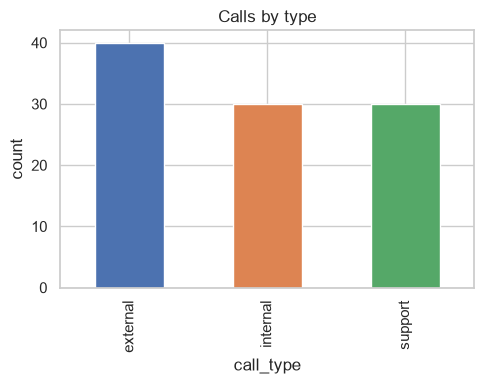

In [3]:
print(meetings["call_type"].value_counts())
print()
fig, ax = plt.subplots(figsize=(5, 4))
meetings["call_type"].value_counts().plot.bar(ax=ax, color=sns.color_palette("deep", 3))
ax.set_title("Calls by type")
ax.set_ylabel("count")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/call_type_counts.png", dpi=150)
plt.show()


## 1. Topic / theme categorization

### Why a hybrid approach, and how we got there (including a dead end)

We tried three things, in order, and kept what worked:

**Attempt 1 — pure unsupervised clustering.** Encode each call's title + summary + topics with a
sentence embedding model (`all-MiniLM-L6-v2`, local, no API needed), then KMeans over a sweep of
k. Best silhouette score across k=5..12 topped out at **~0.066** — weak separation. Not surprising
in hindsight: these are all professional B2B calls from the same vendor, so a huge amount of
surface vocabulary (politeness markers, product names, "thanks for jumping on") is shared across
every category. Clustering alone gave fuzzy, hard-to-defend groupings.

**Attempt 2 — naive keyword rules over the `topics` field.** Every call already has 4-6 short
topic tags extracted upstream (e.g. `"outage"`, `"renewal"`, `"hipaa compliance"`). A first version
mapped keywords like `"incident"` straight to an "Incident & Outage" theme — and put **55 of 100**
calls in that bucket. Too many. The reason: a live outage is a running storyline that quarter, so
tags like `"incident post-mortem"` or `"technical incident"` show up on renewal calls, SOC-2 audit
prep, and engineering standups that merely *reference* the outage, without being *about* it.

**Attempt 3 (final) — title-pattern-first, topic-tags as a narrow tie-breaker.** The company
already names calls consistently (see call-type section above). We use that as the primary signal,
and only fall back to topic tags — with tight, compound-phrase matching (e.g. `"platform outage"`,
not bare `"outage"`) — for the two title patterns that are genuinely ambiguous: numbered support
cases, and `"Aegis / <Customer>"` account calls. This is fully explainable to a support/sales
leader ("why is this call tagged Compliance?") and costs nothing to run.

**Embeddings still earn their keep** — not as the categorizer, but as a **validation layer**: for
every call we compute cosine similarity to its assigned theme's centroid vs. the closest
*alternative* theme, and flag anything where the alternative wins. That surfaces genuinely
ambiguous calls for human review, and we also cross-check the rule labels against an independent
KMeans(k=9) clustering using Adjusted Mutual Information — a sanity number, not a target to game.


In [4]:
meetings = categorize.add_theme_column(meetings)
print(meetings["theme"].value_counts())


theme
Product Roadmap & Planning             19
Incident & Outage Management           19
Commercial: Renewal & Retention        18
Technical Support & Bug Resolution     13
Product Feedback & Feature Requests     9
Compliance & Audit                      8
Competitive Intelligence                6
Onboarding & Deployment                 4
Billing & Account Issues                4
Name: count, dtype: int64


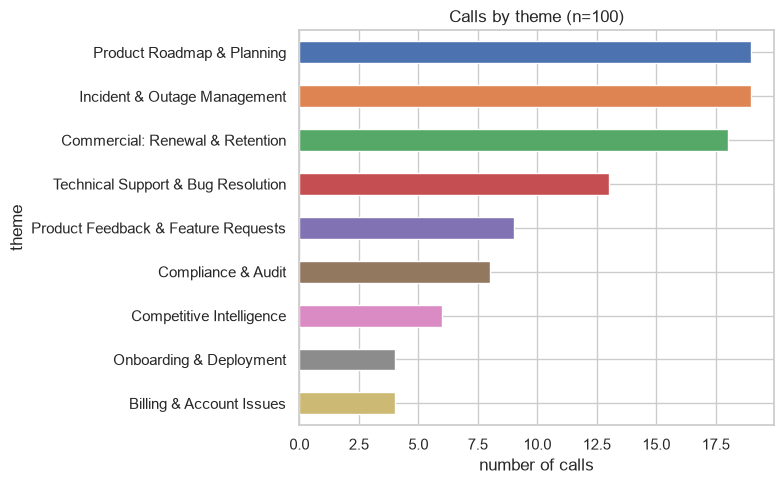

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
order = meetings["theme"].value_counts().index
meetings["theme"].value_counts().loc[order].plot.barh(ax=ax, color=sns.color_palette("deep", 9))
ax.set_xlabel("number of calls")
ax.set_title("Calls by theme (n=100)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/theme_counts.png", dpi=150)
plt.show()


### Theme × call type — who talks about what

This cross-tab is arguably more useful to a stakeholder than the theme counts alone: it shows
*which audience* each theme shows up for. Compliance shows up in both internal (SOC-2 prep) and
external (customer audit reviews) contexts — useful for a PM deciding whether compliance tooling
is an internal or customer-facing priority. Incidents touch **all three** call types — a first
signal (developed further in section 3) that reliability problems aren't just an engineering
concern.


In [6]:
pd.crosstab(meetings["theme"], meetings["call_type"])


call_type,external,internal,support
theme,,,
Billing & Account Issues,0,0,4
Commercial: Renewal & Retention,18,0,0
Competitive Intelligence,2,4,0
Compliance & Audit,6,2,0
Incident & Outage Management,4,7,8
Onboarding & Deployment,4,0,0
Product Feedback & Feature Requests,4,0,5
Product Roadmap & Planning,2,17,0
Technical Support & Bug Resolution,0,0,13


### Validating the taxonomy

1. **Embedding-similarity margin** — for each call, similarity to its own theme's centroid minus
   similarity to the best-fitting alternative theme. Negative margin = a genuine borderline case.


In [7]:
embeddings = categorize.embed_meetings(meetings)
meetings = categorize.validate_themes(meetings, embeddings)

print(meetings["theme_fit_margin"].describe().round(3))
flagged = meetings[meetings["theme_fit_margin"] < 0].sort_values("theme_fit_margin")
print(f"\n{len(flagged)} / {len(meetings)} calls flagged as borderline (their embedding is actually "
      f"closer to a different theme than the one they were assigned):")
flagged[["title", "theme", "closest_alt_theme", "theme_fit_margin"]]


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

count    100.000
mean       0.100
std        0.062
min       -0.079
25%        0.058
50%        0.101
75%        0.140
max        0.242
Name: theme_fit_margin, dtype: float64

4 / 100 calls flagged as borderline (their embedding is actually closer to a different theme than the one they were assigned):


,title,theme,closest_alt_theme,theme_fit_margin
31,Aegis / Ridgeline Logistics - Identity Roadmap Discussion,Product Roadmap & Planning,Commercial: Renewal & Retention,-0.079190
58,Aegis / Summit Trust - Platform Concerns Discussion,Incident & Outage Management,Commercial: Renewal & Retention,-0.054156
15,Aegis / Frostbyte AI - Identity Module Setup,Commercial: Renewal & Retention,Onboarding & Deployment,-0.010893
84,Aegis / Coastal Living Co - Protect Module Expansion,Commercial: Renewal & Retention,Onboarding & Deployment,-0.007259


A ~4% borderline rate is a healthy sign, not a problem — these are genuinely ambiguous calls (e.g.
an "Identity Roadmap Discussion" that's also very renewal-flavored, since it's still an
account-manager-led relationship call). A rule set with *zero* borderline cases on real-world data
would be more suspicious — it would suggest the rules are overfit to the exact wording rather than
the semantics.

2. **Independent clustering agreement** — does an unsupervised KMeans(k=9) over the same embeddings
   land on groupings that resemble our rule-based themes? We use Adjusted Mutual Information (AMI),
   which corrects for chance agreement (0 = no better than random, 1 = perfect agreement).


In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_mutual_info_score

km = KMeans(n_clusters=9, random_state=42, n_init=10).fit(embeddings)
ami = adjusted_mutual_info_score(meetings["theme"], km.labels_)
print(f"Adjusted Mutual Information (rule-based themes vs. independent clustering): {ami:.3f}")


Adjusted Mutual Information (rule-based themes vs. independent clustering): 0.386


0.39 is moderate, positive agreement between two *independent* methods (one supervised-by-rules,
one fully unsupervised) — meaningful corroboration without the false confidence of a suspiciously
perfect score. Combined with the low borderline rate, this taxonomy is defensible to present to
stakeholders as-is, while the fit-margin column gives a ready-made review queue for anything new.

### Example transcripts per category

One representative call per theme, so the categories are concrete rather than abstract labels.


In [9]:
for theme in meetings["theme"].value_counts().index:
    ex = meetings[meetings["theme"] == theme].iloc[0]
    print(f"--- {theme} ---")
    print(f"[{ex['call_type']}] {ex['title']}")
    print(f"Topics: {', '.join(ex['topics'])}")
    print(f"Summary: {ex['summary'][:220]}...")
    print()


--- Product Roadmap & Planning ---
[internal] Detect Team - Sprint Planning
Topics: sprint planning, pipeline architecture, single point of failure, ci/cd improvement, capacity planning, sprint retrospective
Summary: The team held a sprint twelve planning meeting that began with a quick retrospective on sprint eleven, where seven of nine tickets were completed. Key carry-overs include alert deduplication and a pipeline latency invest...

--- Incident & Outage Management ---
[support] URGENT: Cobalt Software - Aegis Detect Dashboard Down
Topics: outage, platform reliability, threat monitoring, churn risk, incident response, service credit
Summary: Lauren Bishop, VP of Infrastructure at Cobalt Software, called Aegis Cloud Security support reporting that their Aegis Detect dashboard was completely down with no threat visibility for nearly an hour. David Kim investig...

--- Commercial: Renewal & Retention ---
[external] Aegis / Blackridge Investments - Renewal Discussion
Topics: renewal, 

## 2. Sentiment analysis across call types

### Trusting, but verifying, the dataset's own sentiment labels

Every call already has a per-sentence `sentimentType` and a per-call `overallSentiment` +
continuous `sentimentScore` (1-5). Rather than re-deriving sentiment from raw text with a fresh
model (which would just be a noisier version of work already done upstream), we **independently
cross-check** the existing labels with VADER — a lexicon-based sentiment scorer that has nothing to
do with whatever pipeline produced this dataset — and report how well the two agree, at two levels
of granularity.


In [10]:
sentences = sentiment.score_with_vader(sentences)
raw_agreement = sentiment.agreement_rate(sentences)
print(f"Per-sentence 3-class label agreement (VADER vs. dataset): {raw_agreement:.1%}")
print()
print("Dataset sentiment_type distribution:")
print(sentences["sentiment_type"].value_counts(normalize=True).round(3))
print()
print("VADER label distribution:")
print(sentences["vader_label"].value_counts(normalize=True).round(3))


Per-sentence 3-class label agreement (VADER vs. dataset): 37.0%

Dataset sentiment_type distribution:
sentiment_type
neutral     0.563
positive    0.270
negative    0.167
Name: proportion, dtype: float64

VADER label distribution:
vader_label
positive    0.778
negative    0.124
neutral     0.098
Name: proportion, dtype: float64


That 37% raw agreement looks bad in isolation — but look at *why*: VADER calls 78% of sentences
positive, because ordinary conversational politeness ("sure", "thanks", "that's helpful") reads as
positive to a general-purpose lexicon. The dataset's own model is far more conservative (56%
neutral) — appropriately so, since most of a business call is genuinely neutral logistics, not
positive or negative sentiment. **The two models disagree about where the neutral/positive line
sits, not about overall direction.** We can check that directly by aggregating to the call level:


Correlation between mean VADER compound score and the dataset's own sentiment_score, aggregated per call: 0.841


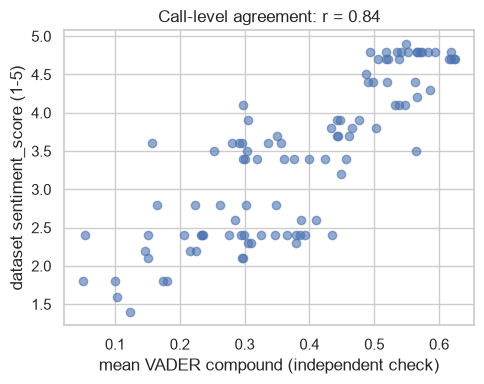

In [11]:
call_level = sentences.groupby("meeting_id")["vader_compound"].mean().rename("mean_vader_compound")
check = meetings.set_index("meeting_id")[["sentiment_score"]].join(call_level)
corr = check.corr().iloc[0, 1]
print(f"Correlation between mean VADER compound score and the dataset's own sentiment_score, "
      f"aggregated per call: {corr:.3f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(check["mean_vader_compound"], check["sentiment_score"], alpha=0.6)
ax.set_xlabel("mean VADER compound (independent check)")
ax.set_ylabel("dataset sentiment_score (1-5)")
ax.set_title(f"Call-level agreement: r = {corr:.2f}")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/sentiment_validation.png", dpi=150)
plt.show()


**r ≈ 0.84** — strong agreement once you look at the right granularity. That's the evidence we
need to trust `sentiment_score` for the trend analysis below, and it's a more honest validation
story than either (a) blindly trusting the provided labels with no check, or (b) reporting the
misleading 37% number without explaining it.

### Sentiment by call type — the headline numbers


In [12]:
sentiment.call_type_sentiment_summary(meetings)


,n_calls,avg_sentiment_score,pct_negative_or_mixed_negative,avg_churn_signals,avg_concerns,avg_technical_issues,avg_positive_pivots
call_type,,,,,,,
external,40,3.852,0.250,0.575,0.800,0.250,0.875
internal,30,3.423,0.333,0.433,0.767,0.733,0.867
support,30,2.827,0.633,0.833,0.967,0.733,0.500


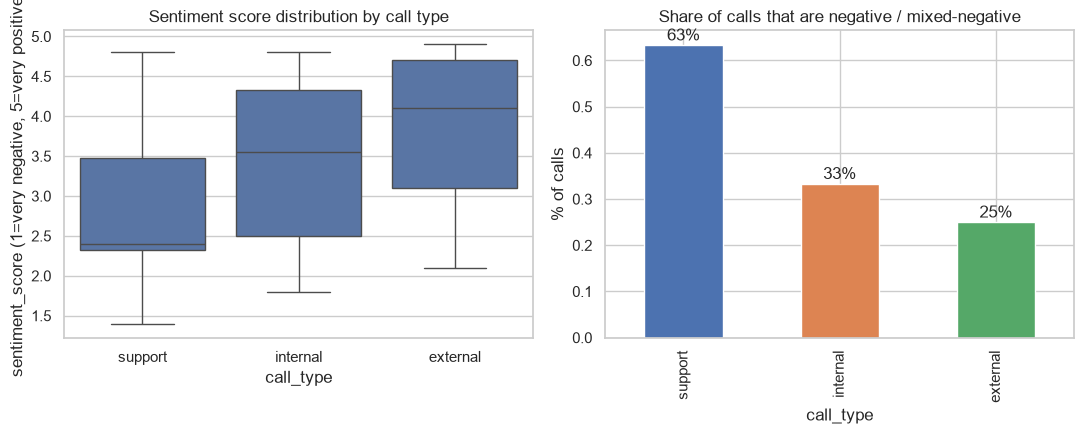

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.boxplot(data=meetings, x="call_type", y="sentiment_score", ax=axes[0],
            order=["support", "internal", "external"])
axes[0].set_title("Sentiment score distribution by call type")
axes[0].set_ylabel("sentiment_score (1=very negative, 5=very positive)")

neg_share = meetings.groupby("call_type", observed=True)["overall_sentiment"].apply(
    lambda s: s.isin(["negative", "very-negative", "mixed-negative"]).mean()
).loc[["support", "internal", "external"]]
neg_share.plot.bar(ax=axes[1], color=sns.color_palette("deep", 3))
axes[1].set_title("Share of calls that are negative / mixed-negative")
axes[1].set_ylabel("% of calls")
for i, v in enumerate(neg_share):
    axes[1].text(i, v + 0.01, f"{v:.0%}", ha="center")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/sentiment_by_call_type.png", dpi=150)
plt.show()


**Support calls run coldest** (lowest average score, highest share of negative/mixed-negative) —
expected, since customers only file a support case when something is already broken. **External
(account-manager-led) calls run warmest** — also expected, renewal and roadmap conversations are
inherently more relationship-positive than a bug report. The more interesting story is *when* each
call type dips, not just its baseline — which is what the time trend below shows.

### Sentiment by theme — which conversation topics run hottest / coldest


In [14]:
sentiment.theme_sentiment_summary(meetings)


,n_calls,avg_sentiment_score,pct_negative_or_mixed_negative
theme,,,
Incident & Outage Management,19,2.221,0.947
Technical Support & Bug Resolution,13,2.585,0.846
Competitive Intelligence,6,2.817,0.667
Billing & Account Issues,4,3.450,0.250
Product Roadmap & Planning,19,3.900,0.053
Commercial: Renewal & Retention,18,3.922,0.222
Product Feedback & Feature Requests,9,4.078,0.000
Compliance & Audit,8,4.412,0.000
Onboarding & Deployment,4,4.600,0.000


Unsurprising but worth stating plainly: **Incident & Outage** and **Technical Support & Bug**
themes are the coldest (avg ~2.1-2.6, 85-95% negative/mixed-negative), while **Product Roadmap**,
**Compliance & Audit**, and **Onboarding & Deployment** run consistently positive. This says
something a leadership team should care about: *the sentiment problem in this business is
concentrated, not diffuse* — it's not that customers are generally unhappy, it's that reliability
and bug-resolution conversations are where the temperature drops. That's an actionable, narrow
target rather than a vague "improve customer sentiment" mandate.

### The trend that matters most: a single incident's sentiment shockwave

Grouping by week reveals a sharp, synchronized dip across **all three call types** in mid-March —
right when the "Detect Outage" incident cluster of calls happened (Mar 10-18: war room →
escalation bridge → customer impact assessment → root cause analysis → remediation plan →
post-incident review).


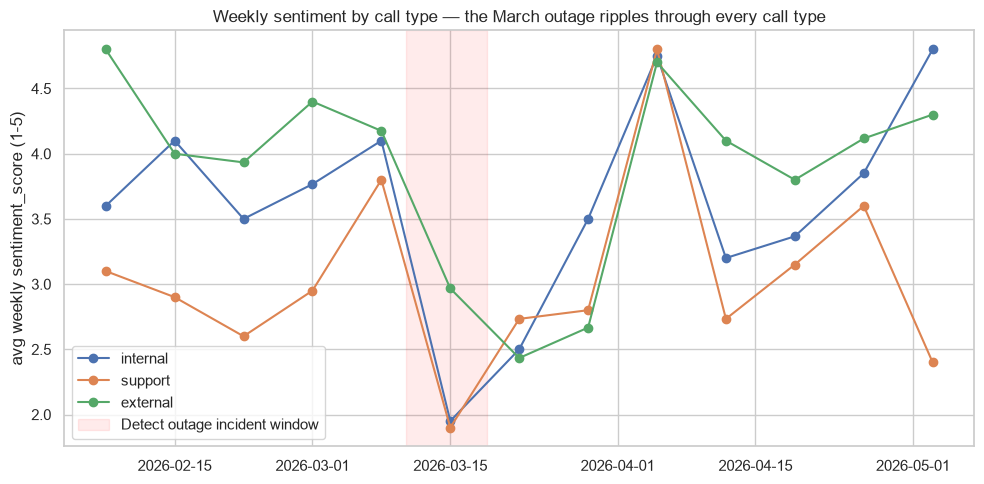

call_type,external,internal,support
start_time,,,
2026-02-08 00:00:00+00:00,4.80,3.60,3.10
2026-02-15 00:00:00+00:00,4.00,4.10,2.90
2026-02-22 00:00:00+00:00,3.93,3.50,2.60
2026-03-01 00:00:00+00:00,4.40,3.77,2.95
2026-03-08 00:00:00+00:00,4.18,4.10,3.80
2026-03-15 00:00:00+00:00,2.97,1.95,1.90
2026-03-22 00:00:00+00:00,2.43,2.50,2.73
2026-03-29 00:00:00+00:00,2.67,3.50,2.80
2026-04-05 00:00:00+00:00,4.70,4.75,4.80


In [15]:
weekly = sentiment.sentiment_over_time(meetings, freq="W")
pivot = weekly.pivot(index="start_time", columns="call_type", values="sentiment_score")

fig, ax = plt.subplots(figsize=(10, 5))
for ct, color in zip(["internal", "support", "external"], sns.color_palette("deep", 3)):
    ax.plot(pivot.index, pivot[ct], marker="o", label=ct, color=color)

incident_calls = meetings[meetings["title"].str.contains("Detect Outage|INCIDENT:", regex=True)]
ax.axvspan(incident_calls["start_time"].min(), incident_calls["start_time"].max(),
           color="red", alpha=0.08, label="Detect outage incident window")
ax.set_ylabel("avg weekly sentiment_score (1-5)")
ax.set_title("Weekly sentiment by call type — the March outage ripples through every call type")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/sentiment_trend.png", dpi=150)
plt.show()
pivot.round(2)


### What this trend means, and why someone should care

- **Internal sentiment craters first and hardest** (4.10 → 1.95 in one week) — the engineering
  org absorbs the initial shock of the incident, as you'd expect from war-room and root-cause calls.
- **External (AM-led) sentiment craters almost as much, in the same week** (4.18 → 2.97 → 2.43) —
  account managers are having hard conversations with customers in real time, not after the fact.
- **Support sentiment stays depressed for two weeks *longer*** than internal/external (1.90 → 2.73
  → 2.80, only recovering in the week of Apr 5) — this is the long tail of an incident: individual
  customer tickets keep arriving and stay negative even after the "big" internal and relationship
  conversations have moved on to remediation.
- **All three recover to the best sentiment levels in the entire dataset the week immediately after**
  (4.70-4.80 across the board, week of Apr 5) — consistent with an effective remediation and
  post-incident review closing the loop, and probably a wave of relationship-repair conversations
  landing well.

**Why this should matter to engineering & product leadership:** a reliability incident's cost isn't
just the outage window — it has a **quantifiable, multi-week trailing tax on customer support
sentiment that outlasts the internal "this is resolved" milestone by roughly two weeks.** That's a
staffing and process signal (proactive post-incident support outreach could shorten the tail), and
it's also a commercial risk signal — this is precisely the window where "churn risk" topic tags
cluster (see the account health scores in section 3), meaning **renewal conversations scheduled in
the weeks right after an incident carry extra risk and deserve extra care.**


## 3. Beyond the required tasks — what else can this data tell us?

Three ideas below: the first two are fully implemented against the real dataset; a few more are
described conceptually at the end (per the assignment's own guidance that "a well-articulated idea
you didn't code is more valuable... than a half-baked implementation").

### 3.1 Incident blast radius — turning a reliability event into a business-risk number

The time-trend above shows sentiment *direction*. This turns it into a business number: how many
distinct customer accounts were touched by the March incident, and by how much did their sentiment
move, in absolute terms?


In [16]:
blast = insights.incident_blast_radius(meetings)
print("Incident window:", blast["incident_window_start"].date(), "to", blast["incident_window_end"].date())
print()
print(blast["incident_calls"].to_string(index=False))
print()
print(f"Distinct customer accounts touched by support/external calls within 3 weeks of the "
      f"incident starting: {blast['n_affected_customers']}")
print(blast["affected_customers"])
print()
print("Baseline sentiment (before the incident):")
print(blast["baseline_sentiment_by_type"])
print()
print("Trough sentiment (during the incident window):")
print(blast["trough_sentiment_by_type"])


Incident window: 2026-03-10 to 2026-03-31

                                                            title                start_time
                     INCIDENT: Detect Pipeline Failure - War Room 2026-03-10 13:15:00+00:00
                                Detect Outage - Escalation Bridge 2026-03-11 11:00:00+00:00
          Aegis / Northstar Pharma - Urgent: Detect Outage Impact 2026-03-12 12:15:00+00:00
                       Detect Outage - Customer Impact Assessment 2026-03-12 13:45:00+00:00
                              Detect Outage - Root Cause Analysis 2026-03-14 14:30:00+00:00
ESCALATION: Northstar Pharma - Detect Outage Impact on Compliance 2026-03-15 14:30:00+00:00
                          Detect Outage - Remediation Plan Review 2026-03-16 09:30:00+00:00
                             Detect Outage - Post-Incident Review 2026-03-18 16:30:00+00:00

Distinct customer accounts touched by support/external calls within 3 weeks of the incident starting: 15
['blackridgeinvest.com'

**Why product/engineering leadership should care:** in this sample, **15 of roughly 35 active
customer accounts** (~43%) show up in a support or account-management conversation within three
weeks of a single pipeline failure — and average sentiment for every call type roughly *halved*
during that window (e.g. support: 3.07 → 1.4). Reliability isn't an abstract engineering metric
here; it has a directly measurable, dollar-adjacent blast radius. This is the kind of number that
turns "we should invest more in resilience" from an opinion into a quantified trade-off.

### 3.2 Account health score — a ranked worklist for CS / sales leaders

A single call's sentiment is a data point; a customer relationship's *trend* across every call
they've had with us is the actual signal a CS or sales leader needs. This blends per-account
average sentiment, churn-risk topic-tag frequency, and churn/concern key-moments into one
auditable 0-100 score (see `insights.account_health_scores` for the exact weighting — deliberately
simple and inspectable rather than a black-box model).


In [17]:
health = insights.account_health_scores(meetings)
print("Weakest accounts (top priority for CS/AM outreach):")
health.head(8)[["customer_domain", "n_calls", "avg_sentiment_score", "pct_calls_with_churn_topic", "health_score"]]


Weakest accounts (top priority for CS/AM outreach):


,customer_domain,n_calls,avg_sentiment_score,pct_calls_with_churn_topic,health_score
0,northstarpharma.com,2,2.10,1.0,13.8
1,helixdata.io,1,2.30,1.0,24.6
2,novaretail.com,2,2.45,0.5,39.0
3,cobaltsoftware.com,2,2.60,0.5,40.8
4,steelpointmfg.com,2,2.60,0.5,40.8
5,trailheadmkt.com,2,2.95,0.5,45.2
6,ironcladfinancial.com,1,2.80,0.0,47.5
7,quantumedge.com,1,2.40,0.0,50.8


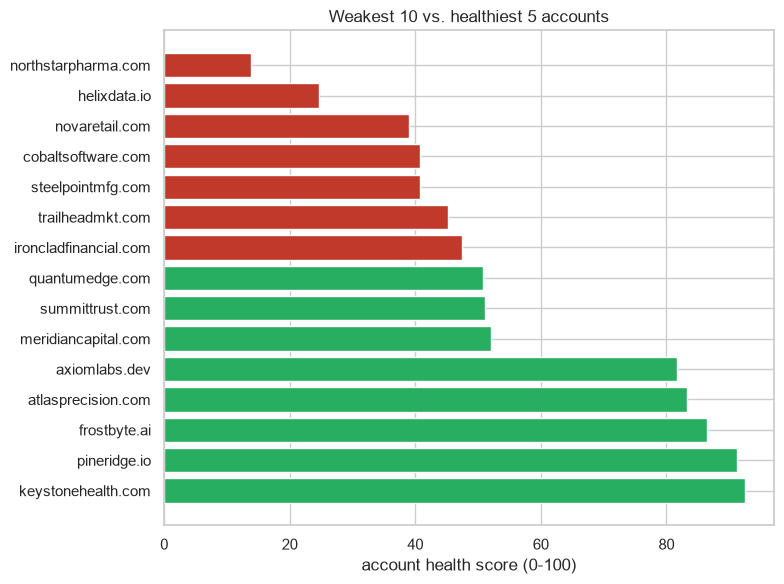

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
sample = pd.concat([health.head(10), health.tail(5)])
colors = ["#c0392b" if v < 50 else "#27ae60" for v in sample["health_score"]]
ax.barh(sample["customer_domain"], sample["health_score"], color=colors)
ax.set_xlabel("account health score (0-100)")
ax.set_title("Weakest 10 vs. healthiest 5 accounts")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/account_health.png", dpi=150)
plt.show()


**Why a sales/CS leader should care:** this is a ready-made prioritized worklist, not a report to
read through. `northstarpharma.com` scores 13.8/100 — both of their calls were incident-driven and
100% churn-topic-tagged. That account should have a proactive save-play *before* their renewal
conversation happens, not be discovered as "at risk" during it.

### 3.3 Talk-time balance — a lightweight call-quality / coaching signal

Using the join/leave-style per-utterance timestamps already in `transcript.json`, we can compute
what share of a customer-facing call's speaking time is held by Aegis vs. the customer. (The
dataset doesn't label which company each speaker belongs to — we infer it: a speaker name that
appears across more than one customer account, or on any internal-only call, must be Aegis staff;
every other name belongs to that single customer. This cleanly partitions all 76 speaker names in
the sample with zero ambiguity.)


In [19]:
aegis_speakers = insights.identify_aegis_speakers(sentences, meetings)
print(f"Identified {len(aegis_speakers)} Aegis-side speakers across {sentences['speaker_name'].nunique()} total")

talk = insights.talk_time_balance(sentences, meetings, aegis_speakers)
print()
print(talk["aegis_share"].describe().round(3))
print()
print("Most Aegis-led calls (rep talks most):")
print(talk.head(5)[["title", "call_type", "aegis_share"]].to_string(index=False))
print()
print("Most customer-led calls (customer talks most):")
print(talk.tail(5)[["title", "call_type", "aegis_share"]].to_string(index=False))


Identified 27 Aegis-side speakers across 76 total

count    70.000
mean      0.574
std       0.044
min       0.468
25%       0.544
50%       0.579
75%       0.594
max       0.671
Name: aegis_share, dtype: float64

Most Aegis-led calls (rep talks most):
                                                        title call_type  aegis_share
         Aegis / Harborview Banking - Threat Detection Tuning  external     0.671175
Support Case #7615 - Crestline Wealth Group Policy Sync Delay   support     0.660904
    Aegis / Clearwater Medical - Comply v2 Deployment Kickoff  external     0.651942
                  Aegis / Maplewood Goods - SOC 2 Prep Review  external     0.647729
 Support Case #7572 - Brightpath Commerce Invoice Discrepancy   support     0.638337

Most customer-led calls (customer talks most):
                                               title call_type  aegis_share
 Aegis / Summit Trust - Platform Concerns Discussion  external     0.497046
             Aegis / Quantum Edge - R

On this sample, turn-taking is fairly balanced (43-67% Aegis share, nothing extreme) — so nothing
is flagged at a strict 70/30 threshold. That's a legitimate finding worth stating plainly rather
than forcing a dramatic result: **this particular sample doesn't show call-quality problems on
this dimension.** The more useful takeaway is the *pattern* at the two ends — competitive
evaluation and renewal-concern calls are the most customer-led (good: those are listening
occasions), while product demos and deployment kickoffs are the most rep-led (expected: those are
presenting occasions). If this metric were run on live production call volume, it would be the
kind of thing a support/AM manager checks per-rep, not just per-call, to catch a rep who
consistently talks over customers on calls that should be discovery-oriented.

### A few more ideas (described, not implemented)

- **Action-item accountability tracking.** Every call already has structured `actionItems` with
  an owner and a commitment. Parsing owner names and matching them against later calls could
  surface a "committed but never followed up" rate per person or per team — a good leading
  indicator for both engineering execution and AM follow-through, and a natural extension once
  there's a reliable way to link a commitment in one call to its resolution in a later one.
- **Competitive-mention early warning.** `"competitive threat"` / `"competitive evaluation"` topic
  tags, cross-referenced with account health scores, would let a sales leader see *which*
  low-health accounts are also actively evaluating a competitor — a much sharper "save this
  account now" signal than sentiment alone.
- **Next-best-action per call.** Given a call's theme + sentiment + key moments, suggest the AM's
  or support rep's next concrete step (e.g. "schedule an executive check-in", "escalate to
  engineering") — essentially turning today's manual `actionItems` summarization into a
  recommendation, not just a transcript of what was already said.


## Closing notes on the dataset itself

The FAQ explicitly invites relabeling/augmenting the sample. I did **not** generate synthetic
transcripts — the 100 provided calls were rich enough (they already carry topics, sentiment, and
key moments) that the higher-value work was building a defensible taxonomy and validated sentiment
pipeline on top of real data, rather than manufacturing more of it. The one thing I *did* add on
top of the raw dataset is derived, not synthetic: `call_type` and `theme` labels, both fully
rule-based and auditable back to the source fields.
